<a href="https://colab.research.google.com/github/agraish/Belajar_GIT/blob/main/Copy_of_Untitled27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import library utama
import pandas as pd

In [ ]:
# load dataset
df = pd.read_csv("OnlineRetail.csv", encoding='latin1')

# tampilkan 5 data pertama
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125339 entries, 0 to 125338
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    125339 non-null  object 
 1   StockCode    125339 non-null  object 
 2   Description  124994 non-null  object 
 3   Quantity     125338 non-null  float64
 4   InvoiceDate  125338 non-null  object 
 5   UnitPrice    125338 non-null  float64
 6   CustomerID   84465 non-null   float64
 7   Country      125338 non-null  object 
dtypes: float64(3), object(5)
memory usage: 7.7+ MB


In [ ]:
# CEK MISSING VALUE
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,345
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,40874
Country,1


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,125338.000000,125338.000000,84465.00000
mean,8.923032,5.299422,15309.01738
std,301.800019,111.195412,1741.71487
min,-74215.000000,0.000000,12346.00000
25%,1.000000,1.250000,13894.00000
50%,3.000000,2.460000,15235.00000
75%,9.000000,4.240000,16904.00000
max,74215.000000,16888.020000,18283.00000


In [ ]:
df_clean = df.copy()

In [ ]:
# HAPUS MISSING CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

In [ ]:
# HAPUS DESCRIPTION KOSONG
df_clean = df_clean.dropna(subset=['Description'])

In [ ]:
# HAPUS DATA ANEH
# hapus Quantity negatif
df_clean = df_clean[df_clean['Quantity'] > 0]

# hapus harga 0 atau negatif
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82275 entries, 0 to 125296
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    82275 non-null  object 
 1   StockCode    82275 non-null  object 
 2   Description  82275 non-null  object 
 3   Quantity     82275 non-null  float64
 4   InvoiceDate  82275 non-null  object 
 5   UnitPrice    82275 non-null  float64
 6   CustomerID   82275 non-null  float64
 7   Country      82275 non-null  object 
dtypes: float64(3), object(5)
memory usage: 5.6+ MB


In [ ]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,82275.000000,82275.000000,82275.000000
mean,13.650185,3.215089,15317.972750
std,263.162002,10.143976,1741.988519
min,1.000000,0.060000,12346.000000
25%,2.000000,1.250000,13911.000000
50%,5.000000,1.950000,15270.000000
75%,12.000000,3.750000,16913.000000
max,74215.000000,1687.170000,18283.000000


In [ ]:
# DROP KOLOM TIDAK PERLU
df_clean = df_clean.drop(['Description', 'InvoiceNo'], axis=1)

In [ ]:
# UBAH TANGGAL
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ambil fitur penting dari tanggal
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day

In [ ]:
# hapus kolom asli
df_clean = df_clean.drop('InvoiceDate', axis=1)

In [ ]:
# ENCODING
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_clean['StockCode'] = le.fit_transform(df_clean['StockCode'])
df_clean['Country'] = le.fit_transform(df_clean['Country'])

In [ ]:
df_clean.head()

,StockCode,Quantity,UnitPrice,CustomerID,Country,Year,Month,Day
0,2546,6.0,2.55,17850.0,29,2010,12,1
1,2026,6.0,3.39,17850.0,29,2010,12,1
2,2203,8.0,2.75,17850.0,29,2010,12,1
3,2158,6.0,3.39,17850.0,29,2010,12,1
4,2157,6.0,3.39,17850.0,29,2010,12,1


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82275 entries, 0 to 125296
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StockCode   82275 non-null  int64  
 1   Quantity    82275 non-null  float64
 2   UnitPrice   82275 non-null  float64
 3   CustomerID  82275 non-null  float64
 4   Country     82275 non-null  int64  
 5   Year        82275 non-null  int32  
 6   Month       82275 non-null  int32  
 7   Day         82275 non-null  int32  
dtypes: float64(3), int32(3), int64(2)
memory usage: 4.7 MB


In [ ]:
# buat kolom TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [ ]:
# hapus outlier pada Quantity
Q1 = df_clean['Quantity'].quantile(0.25)
Q3 = df_clean['Quantity'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[
    (df_clean['Quantity'] >= Q1 - 1.5 * IQR) &
    (df_clean['Quantity'] <= Q3 + 1.5 * IQR)
]

In [ ]:
Q1 = df_clean['TotalPrice'].quantile(0.25)
Q3 = df_clean['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[
    (df_clean['TotalPrice'] >= Q1 - 1.5 * IQR) &
    (df_clean['TotalPrice'] <= Q3 + 1.5 * IQR)
]

In [ ]:
X = df_clean.drop('TotalPrice', axis=1)
y = df_clean['TotalPrice']

In [ ]:

# IMPORT VISUALISASI
import matplotlib.pyplot as plt
import seaborn as sns

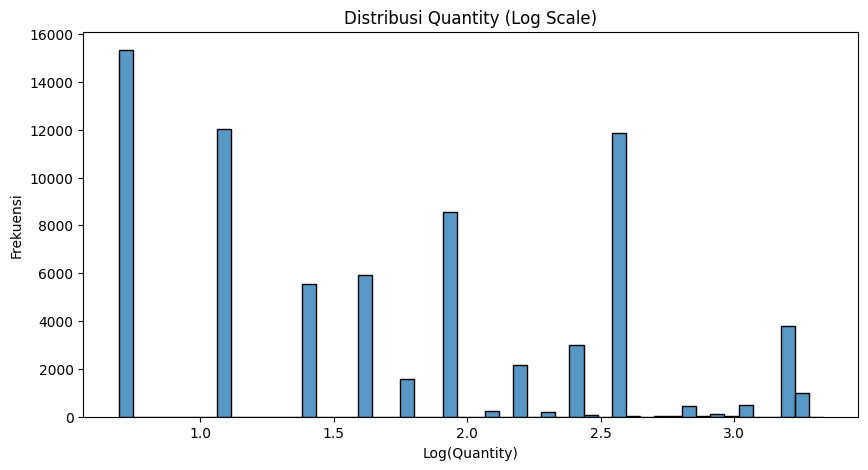

In [ ]:
# DISTRIBUSI DATA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df_clean['Quantity']), bins=50)

plt.title('Distribusi Quantity (Log Scale)')
plt.xlabel('Log(Quantity)')
plt.ylabel('Frekuensi')
plt.show()

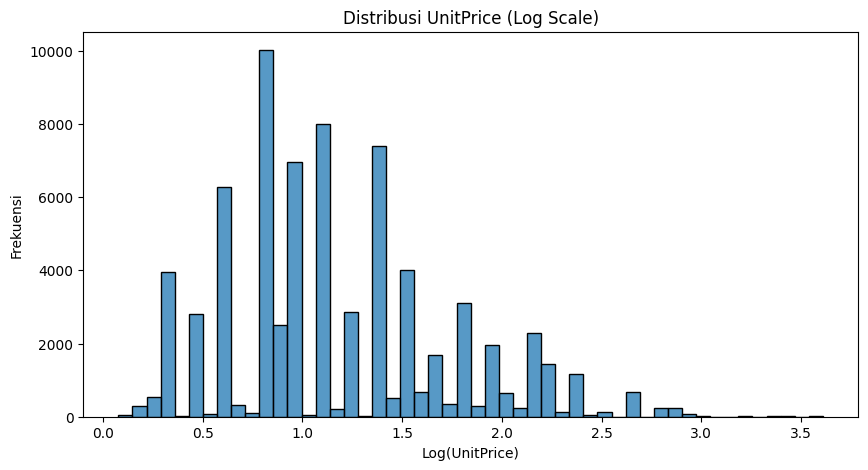

In [ ]:
# DISTRIBUSI UNIT PRICE
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df_clean['UnitPrice']), bins=50)

plt.title('Distribusi UnitPrice (Log Scale)')
plt.xlabel('Log(UnitPrice)')
plt.ylabel('Frekuensi')
plt.show()

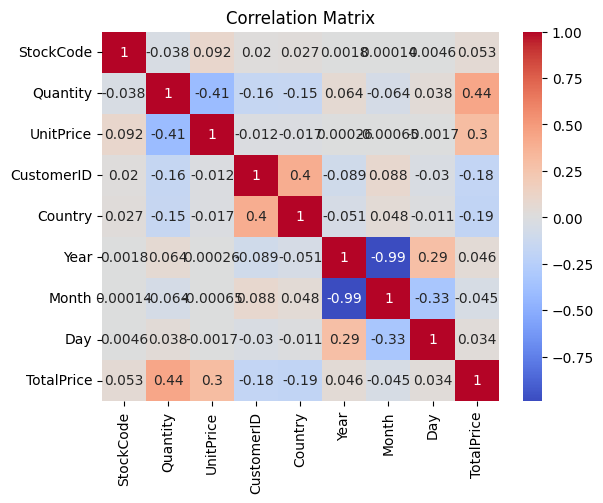

In [ ]:
#Korelasi plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_clean.columns

Index(['StockCode', 'Quantity', 'UnitPrice', 'CustomerID', 'Country', 'Year',
       'Month', 'Day', 'TotalPrice'],
      dtype='object')

In [ ]:
# BUAT TOTAL PRICE
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [ ]:
#Target
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [ ]:
# SPLIT FITUR & TARGET
X = df_clean.drop('TotalPrice', axis=1)
y = df_clean['TotalPrice']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_clean.drop('TotalPrice', axis=1)
y = df_clean['TotalPrice']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

best_knn = KNeighborsRegressor(
    n_neighbors=5,        # biasanya ini yang bagus
    weights='distance'    # sering kasih hasil tinggi
)

best_knn.fit(X_train_80, y_train_80)

KNeighborsRegressor(weights='distance')

In [ ]:
#SPLIT 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
#80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#90:10
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

In [ ]:
# bagi data train dan test
from sklearn.model_selection import train_test_split

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# model knn
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_80, y_train_80)

KNeighborsRegressor()

In [ ]:
# prediksi data test
y_pred_knn = knn.predict(X_test_20)

In [ ]:
# hitung error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_knn = mean_absolute_error(y_test_20, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test_20, y_pred_knn))
r2_knn = r2_score(y_test_20, y_pred_knn)

mae_knn, rmse_knn, r2_knn

(4.8985632326575645, np.float64(6.797299170781075), 0.322392317165092)

In [ ]:
k_values = [5, 7]

hasil_knn = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k, weights='distance')
    model.fit(X_train_80, y_train_80)

    y_pred = model.predict(X_test_20)

    mae = mean_absolute_error(y_test_20, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_20, y_pred))
    r2 = r2_score(y_test_20, y_pred)

    hasil_knn.append([k, mae, rmse, r2])

hasil_knn

[[5, 4.074167879131276, np.float64(6.149533349652448), 0.4453872190792314],
 [7, 4.12396073418483, np.float64(6.128248937788554), 0.44921976293913835]]

In [ ]:
#model terbaik
best_k = max(hasil_knn, key=lambda x: x[3])[0]

best_knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
best_knn.fit(X_train_80, y_train_80)

KNeighborsRegressor(n_neighbors=7, weights='distance')

In [ ]:
# evaluasi model terbaik
y_pred_final = best_knn.predict(X_test_20)

mae_final = mean_absolute_error(y_test_20, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_20, y_pred_final))
r2_final = r2_score(y_test_20, y_pred_final)

mae_final, rmse_final, r2_final

(4.12396073418483, np.float64(6.128248937788554), 0.44921976293913835)

In [ ]:
#INFRENS
# data baru
import pandas as pd

data_baru = pd.DataFrame([{
    'StockCode': 100,
    'Quantity': 10,
    'UnitPrice': 100,
    'CustomerID': 12345,
    'Country': 1,
    'Year': 2011,
    'Month': 12,
    'Day': 5
}])

# samakan kolom
data_baru = data_baru[X.columns]

# prediksi
prediksi = best_knn.predict(data_baru)

prediksi

array([16.19797572])

In [ ]:
# buat model decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_80, y_train_80)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
# prediksi data test
y_pred_dt = dt.predict(X_test_20)

In [ ]:
# evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test_20, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_20, y_pred_dt))
r2_dt = r2_score(y_test_20, y_pred_dt)

mae_dt, rmse_dt, r2_dt

(0.03722253742713594, np.float64(0.22990105292971988), 0.9992248469288815)

In [ ]:
# coba beberapa max_depth
depth_values = [5, 10, 15]

hasil_dt = []

for d in depth_values:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train_80, y_train_80)

    y_pred = model.predict(X_test_20)

    mae = mean_absolute_error(y_test_20, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_20, y_pred))
    r2 = r2_score(y_test_20, y_pred)

    hasil_dt.append([d, mae, rmse, r2])

hasil_dt

[[5, 1.79737123982009, np.float64(2.8358206377508575), 0.8820594716614829],
 [10,
  0.03722253742713594,
  np.float64(0.22990105292971988),
  0.9992248469288815],
 [15, 0.002249344917993072, np.float64(0.063737649256142), 0.9999404203928396]]

In [ ]:
# ambil depth terbaik
best_depth = max(hasil_dt, key=lambda x: x[3])[0]

best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_dt.fit(X_train_80, y_train_80)

DecisionTreeRegressor(max_depth=15, random_state=42)

In [ ]:
y_pred_dt_final = best_dt.predict(X_test_20)

mae_dt_final = mean_absolute_error(y_test_20, y_pred_dt_final)
rmse_dt_final = np.sqrt(mean_squared_error(y_test_20, y_pred_dt_final)
)
r2_dt_final = r2_score(y_test_20, y_pred_dt_final)

mae_dt_final, rmse_dt_final, r2_dt_final

(0.002249344917993072, np.float64(0.063737649256142), 0.9999404203928396)

In [ ]:
# data baru
import pandas as pd

data_baru = pd.DataFrame([{
    'StockCode': 100,
    'Quantity': 10,
    'UnitPrice': 100,
    'CustomerID': 12345,
    'Country': 1,
    'Year': 2011,
    'Month': 12,
    'Day': 5
}])

# samakan kolom
data_baru = data_baru[X.columns]

# prediksi
prediksi_dt = best_dt.predict(data_baru)

prediksi_dt

array([34.])

In [ ]:
# model gradient boosting
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_80, y_train_80)

GradientBoostingRegressor(random_state=42)

In [ ]:
# prediksi data test
y_pred_gbr = gbr.predict(X_test_20)

In [ ]:
# evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gbr = mean_absolute_error(y_test_20, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test_20, y_pred_gbr))
r2_gbr = r2_score(y_test_20, y_pred_gbr)

mae_gbr, rmse_gbr, r2_gbr

(0.4186603842085372, np.float64(0.656033486824331), 0.9936881369418096)

In [ ]:
# coba beberapa learning rate dan depth
params = [
    (0.05, 3),
    (0.1, 3),
    (0.1, 5)
]

hasil_gbr = []

for lr, depth in params:
    model = GradientBoostingRegressor(
        learning_rate=lr,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_80, y_train_80)
    y_pred = model.predict(X_test_20)

    mae = mean_absolute_error(y_test_20, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_20, y_pred))
    r2 = r2_score(y_test_20, y_pred)

    hasil_gbr.append([lr, depth, mae, rmse, r2])

hasil_gbr

[[0.05,
  3,
  0.8380975495143247,
  np.float64(1.340790917550651),
  0.9736350064014297],
 [0.1,
  3,
  0.4186603842085372,
  np.float64(0.656033486824331),
  0.9936881369418096],
 [0.1,
  5,
  0.0835306883205412,
  np.float64(0.15016638034822863),
  0.9996692872211784]]

In [ ]:
best_params = max(hasil_gbr, key=lambda x: x[4])

best_lr = best_params[0]
best_depth = best_params[1]

best_gbr = GradientBoostingRegressor(
    learning_rate=best_lr,
    max_depth=best_depth,
    random_state=42
)

best_gbr.fit(X_train_80, y_train_80)

GradientBoostingRegressor(max_depth=5, random_state=42)

In [ ]:
#evaluasi final
y_pred_gbr_final = best_gbr.predict(X_test_20)

mae_gbr_final = mean_absolute_error(y_test_20, y_pred_gbr_final)
rmse_gbr_final = np.sqrt(mean_squared_error(y_test_20, y_pred_gbr_final))
r2_gbr_final = r2_score(y_test_20, y_pred_gbr_final)

mae_gbr_final, rmse_gbr_final, r2_gbr_final

(0.0835306883205412, np.float64(0.15016638034822863), 0.9996692872211784)

In [ ]:
#inferent
import pandas as pd

data_baru = pd.DataFrame([{
    'StockCode': 100,
    'Quantity': 10,
    'UnitPrice': 100,
    'CustomerID': 12345,
    'Country': 1,
    'Year': 2011,
    'Month': 12,
    'Day': 5
}])

data_baru = data_baru[X.columns]

prediksi_gbr = best_gbr.predict(data_baru)

prediksi_gbr

array([44.05200888])

In [ ]:
# model extra trees
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_80, y_train_80)

ExtraTreesRegressor(random_state=42)

In [ ]:
# prediksi data test
y_pred_etr = etr.predict(X_test_20)

# evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_etr = mean_absolute_error(y_test_20, y_pred_etr)
rmse_etr = np.sqrt(mean_squared_error(y_test_20, y_pred_etr))
r2_etr = r2_score(y_test_20, y_pred_etr)

mae_etr, rmse_etr, r2_etr

(0.0019209281478838884, np.float64(0.03002231477123108), 0.9999867811431518)

In [ ]:
# coba beberapa parameter
params = [50, 100, 200]

hasil_etr = []

for n in params:
    model = ExtraTreesRegressor(n_estimators=n, random_state=42)
    model.fit(X_train_80, y_train_80)

    y_pred = model.predict(X_test_20)

    mae = mean_absolute_error(y_test_20, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_20, y_pred))
    r2 = r2_score(y_test_20, y_pred)

    hasil_etr.append([n, mae, rmse, r2])

hasil_etr

[[50,
  0.0018886636326424784,
  np.float64(0.03041010922035808),
  0.9999864374450336],
 [100,
  0.0019209281478838884,
  np.float64(0.03002231477123108),
  0.9999867811431518],
 [200,
  0.0017912632740771444,
  np.float64(0.02837035709628581),
  0.9999881958381402]]

In [ ]:
# model adaboost
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train_80, y_train_80)

AdaBoostRegressor(random_state=42)

In [ ]:
#prediksi
y_pred_ada = ada.predict(X_test_20)
#evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ada = mean_absolute_error(y_test_20, y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test_20, y_pred_ada))
r2_ada = r2_score(y_test_20, y_pred_ada)

mae_ada, rmse_ada, r2_ada

(3.7389085168439355, np.float64(4.148628829767395), 0.7475852593490298)

In [ ]:
#import
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
#parameter
param_ada = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 1]
}

In [ ]:
grid_ada = GridSearchCV(
    AdaBoostRegressor(random_state=42),
    param_ada,
    cv=2,
    n_jobs=-1
)

grid_ada.fit(X_train_80, y_train_80)

GridSearchCV(cv=2, estimator=AdaBoostRegressor(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100]})

In [ ]:
#TABEL COMPARISON
#perbandingan model
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Gradient Boosting', 'Extra Trees', 'AdaBoost'],

    'MAE': [
        mae_knn,
        mae_dt,
        mae_gbr,
        mae_etr,
        mae_ada
    ],

    'RMSE': [
        rmse_knn,
        rmse_dt,
        rmse_gbr,
        rmse_etr,
        rmse_ada
    ],

    'R2 Score': [
        r2_knn,
        r2_dt,
        r2_gbr,
        r2_etr,
        r2_ada
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,KNN,4.898563,6.797299,0.322392
1,Decision Tree,0.037223,0.229901,0.999225
2,Gradient Boosting,0.418660,0.656033,0.993688
3,Extra Trees,0.001921,0.030022,0.999987
4,AdaBoost,3.738909,4.148629,0.747585


In [ ]:
#model terbaik
# urutkan berdasarkan R2 Score tertinggi
comparison_sorted = comparison.sort_values(by='R2 Score', ascending=False)

comparison_sorted

,Model,MAE,RMSE,R2 Score
3,Extra Trees,0.001921,0.030022,0.999987
1,Decision Tree,0.037223,0.229901,0.999225
2,Gradient Boosting,0.418660,0.656033,0.993688
4,AdaBoost,3.738909,4.148629,0.747585
0,KNN,4.898563,6.797299,0.322392


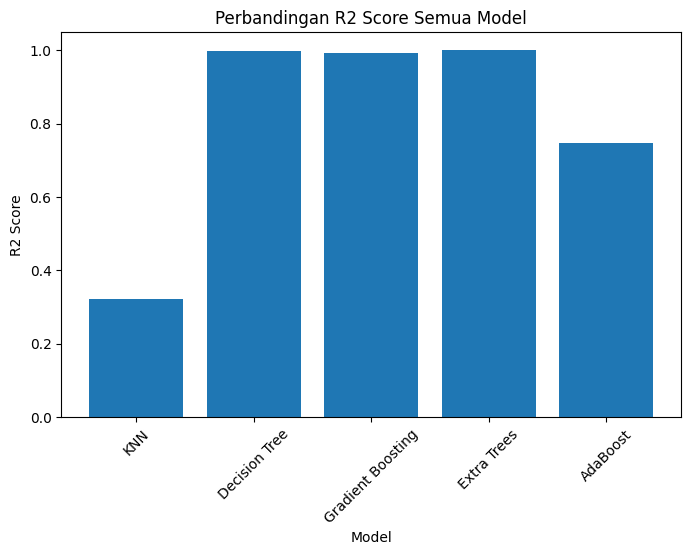

In [ ]:
#grafik perbandingan
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison['Model'], comparison['R2 Score'])
plt.title('Perbandingan R2 Score Semua Model')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.show()

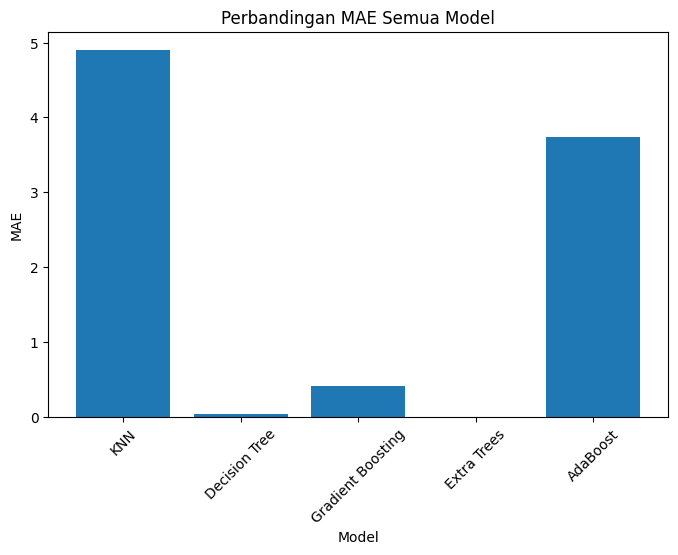

In [ ]:
#grafik error
plt.figure(figsize=(8,5))
plt.bar(comparison['Model'], comparison['MAE'])
plt.title('Perbandingan MAE Semua Model')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.show()

In [ ]:
splitting_results = pd.DataFrame({
    'Split': ['80:20'],
    'Models Used': ['KNN, Decision Tree, Gradient Boosting, Extra Trees, AdaBoost'],
    'Best Model (sementara)': [comparison_sorted.iloc[0]['Model']]
})

splitting_results

,Split,Models Used,Best Model (sementara)
0,80:20,"KNN, Decision Tree, Gradient Boosting, Extra T...",Extra Trees
